In [1]:
import yaml
from ultralytics import YOLO

import os
import sys
sys.path.append(os.path.abspath('..'))

from src.model_utils import smart_predict

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
config = {
    'epochs': 100,
    'save': True,
    'imgsz': 768, 
    'batch': 16,         
    'patience': 20,
    'optimizer': 'AdamW',
    'lr0': 0.001,
    'lrf': 0.01,
    'project': 'runs',
    'plots': True,
    'verbose': True,
    'device': 'cuda',
    'workers': 4,
    'auto_augment': None,
    # 'albumentations':None
}

In [3]:
s1_data = r'..\Data\Processed\Stage 1 (Quadrant Detection)'
s1_data_yaml_path = os.path.join(s1_data,'data.yaml')

s1_data_output = r'..\Runs\Stage 1'

In [4]:
with open(s1_data_yaml_path,'r') as f:

    data_yaml = yaml.safe_load(f)

data_yaml

{'train': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\train\\images',
 'val': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\valid\\images',
 'test': 'C:\\Users\\ibrah.HIMA\\OneDrive\\Desktop\\Full AI\\Projects\\GitHub - Kaggle Projects\\dental-xray-ai\\Data\\Processed\\Stage 1 (Quadrant Detection)\\test\\images',
 'nc': 4,
 'names': ['Upper Right', 'Upper Left', 'Lower Left', 'Lower Right']}

In [ ]:
yolo_model = YOLO('../Models/yolo26s.pt')

In [ ]:
yolo_model.train(data=s1_data_yaml_path,**config,)

New https://pypi.org/project/ultralytics/8.4.92 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.83  Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=None, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=..\Data\Processed\Stage 1 (Quadrant Detection)\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=768, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s.pt, momentum=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001260DB099B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [5]:
quadrant_model_detection = YOLO(os.path.join(s1_data_output,'weights','last.pt'))


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_427.png: 352x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 146.7ms
Speed: 4.5ms preprocess, 146.7ms inference, 0.9ms postprocess per image at shape (1, 3, 352, 768)
Class Name: Lower Right
Coordinates: [847.1632690429688, 653.1796264648438, 1516.8040771484375, 1110.39208984375]
Confidence: %92.0
Class Name: Upper Left
Coordinates: [1486.4825439453125, 384.1766357421875, 2016.4637451171875, 812.8383178710938]
Confidence: %92.0
Class Name: Upper Right
Coordinates: [911.892333984375, 399.66339111328125, 1489.525146484375, 813.6622924804688]
Confidence: %91.0
Class Name: Lower Left
Coordinates: [1505.7269287109375, 627.4683837890625, 2149.14111328125, 1107.3685302734375]
Confidence: %88.0


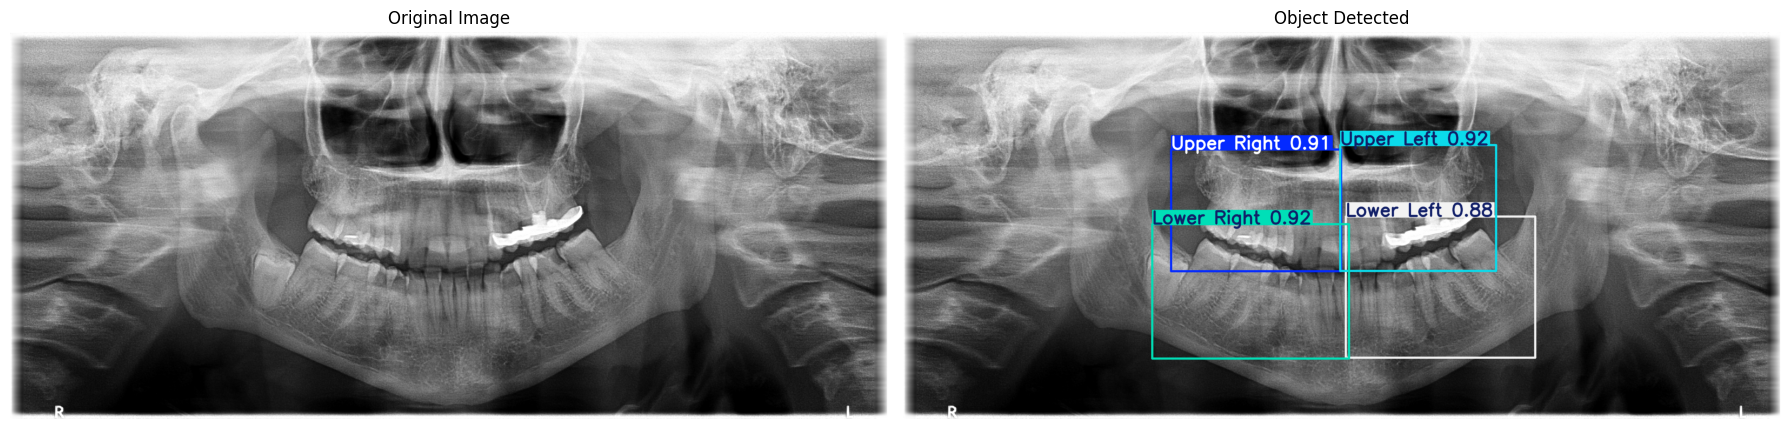

In [9]:
smart_predict(quadrant_model_detection,data_yaml['test'])


image 1/1 C:\Users\ibrah.HIMA\OneDrive\Desktop\Full AI\Projects\GitHub - Kaggle Projects\dental-xray-ai\Data\Processed\Stage 1 (Quadrant Detection)\test\images\train_293.png: 384x768 1 Upper Right, 1 Upper Left, 1 Lower Left, 1 Lower Right, 114.4ms
Speed: 3.9ms preprocess, 114.4ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 768)
Class Name: Lower Left
Coordinates: [1385.916748046875, 660.7355346679688, 2252.978271484375, 1102.791259765625]
Confidence: %92.0
Class Name: Upper Left
Coordinates: [1388.6815185546875, 343.7506408691406, 2206.249267578125, 737.7495727539062]
Confidence: %92.0
Class Name: Upper Right
Coordinates: [584.3236083984375, 317.65362548828125, 1410.177490234375, 720.4795532226562]
Confidence: %89.0
Class Name: Lower Right
Coordinates: [545.4524536132812, 648.0744018554688, 1401.0006103515625, 1105.7593994140625]
Confidence: %82.0


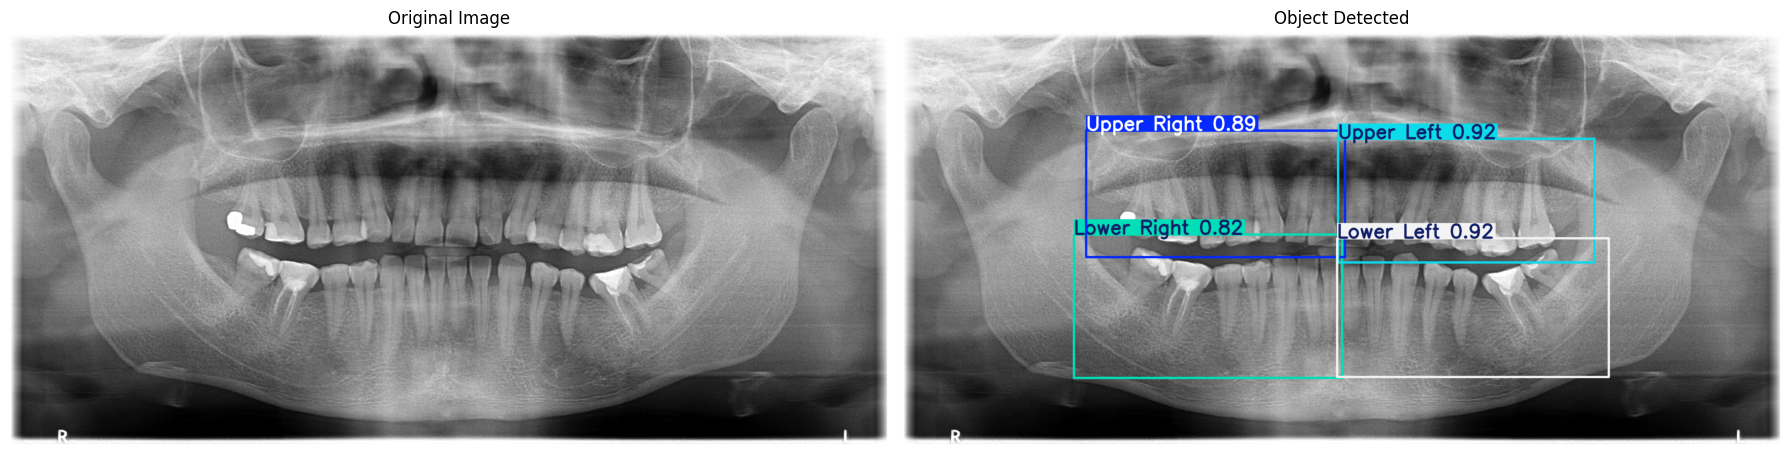

In [15]:
smart_predict(quadrant_model_detection,data_yaml['test'],save_output=True,save_dir=os.path.join(s1_data_output,'Test Outputs Predictions'))